# Verification of the scenario data files - 200e3

These data files include RMa, UMi, UMa files.

**Refactor notes (vs. the previous version of this notebook):**
- Each `.h5` file is opened and loaded into memory **once**, then cached in a
  `SCENARIOS` dict. Every later cell reads from that cache instead of
  re-opening the file from disk, which is what most of the earlier cells did.
- The "Label Integrity" cell had a bug: it reused a leftover `f`/`file`
  variable from an earlier loop instead of looping over all three files, so
  it silently only ever checked the last file. Fixed here.
- The PAPR check existed as three near-identical copy-pasted cells. Merged
  into one.
- The constellation plots now follow your teacher's approach: one panel per
  (modulation, SNR) pair, each showing a small, fixed number of *whole*
  waveform vectors rather than stacking many independent vectors from
  different channel draws into one overlapping scatter cloud.


## 1. Imports and Configuration

In [4]:
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
DATA_DIR = '../data/02-09-2025_4/'

SCENARIO_FILES = {
    'Rma': DATA_DIR + 'Rma.h5',
    'Uma': DATA_DIR + 'Uma.h5',
    'Umi': DATA_DIR + 'Umi.h5',
}

MOD_NAMES = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM', '1024QAM']
EXPECTED_SNRS = np.arange(-10, 21, 2)   # -10, -8, ..., 20 -> 16 values
FOCUS_SNRS = [-10, 0, 10, 20]           # subset used for the constellation grids
TARGET_SNR = 20.0                       # SNR used for energy / PAPR checks

## 2. Load each scenario once

`load_scenario` reads the whole file a single time and pre-computes the
argmax modulation label per row, so nothing downstream needs to touch the
`.h5` file again.

In [6]:
def load_scenario(path):
    """Load one scenario file fully into memory and pre-compute mod labels."""
    with h5py.File(path, 'r') as f:
        data = f['Data'][:]
        mods = f['Mods'][:]
        snrs = f['SNRs'][:]

    mod_idx = np.argmax(mods, axis=1)
    mod_labels = np.array(MOD_NAMES)[mod_idx]

    return {
        'path': path,
        'data': data,
        'mods': mods,
        'snrs': snrs,
        'mod_idx': mod_idx,
        'mod_labels': mod_labels,
    }

SCENARIOS = {}
for label, path in SCENARIO_FILES.items():
    size_mb = Path(path).stat().st_size / 1024**2
    print(f"{label:4s} {path}  ({size_mb:.2f} MB)")
    SCENARIOS[label] = load_scenario(path)

Rma  ../data/02-09-2025_4/Rma.h5  (708.50 MB)
Uma  ../data/02-09-2025_4/Uma.h5  (708.95 MB)
Umi  ../data/02-09-2025_4/Umi.h5  (708.86 MB)


## 3. Initial Global Sanity Checks

In [7]:
for label, s in SCENARIOS.items():
    print(f"---- {label} ----")
    print(f"Data shape/dtype: {s['data'].shape}, {s['data'].dtype}")
    print(f"Mods shape/dtype: {s['mods'].shape}, {s['mods'].dtype}")
    print(f"SNRs shape: {s['snrs'].shape}")
    row_sums = s['mods'].sum(axis=1)
    print(f"Mods row-sum range: [{row_sums.min()}, {row_sums.max()}]")
    print()

---- Rma ----
Data shape/dtype: (98304, 1024), complex64
Mods shape/dtype: (98304, 6), float32
SNRs shape: (98304,)
Mods row-sum range: [1.0, 1.0]

---- Uma ----
Data shape/dtype: (98304, 1024), complex64
Mods shape/dtype: (98304, 6), float32
SNRs shape: (98304,)
Mods row-sum range: [1.0, 1.0]

---- Umi ----
Data shape/dtype: (98304, 1024), complex64
Mods shape/dtype: (98304, 6), float32
SNRs shape: (98304,)
Mods row-sum range: [1.0, 1.0]



## 4. Checking for NaNs and Infs

In [8]:
for label, s in SCENARIOS.items():
    print(f"---- {label} ----")
    for name in ('data', 'mods', 'snrs'):
        arr = s[name]
        print(f"{name:5s} - NaNs: {np.isnan(arr).any()}, Infs: {np.isinf(arr).any()}")
    print()

---- Rma ----
data  - NaNs: False, Infs: False
mods  - NaNs: False, Infs: False
snrs  - NaNs: False, Infs: False

---- Uma ----
data  - NaNs: False, Infs: False
mods  - NaNs: False, Infs: False
snrs  - NaNs: False, Infs: False

---- Umi ----
data  - NaNs: False, Infs: False
mods  - NaNs: False, Infs: False
snrs  - NaNs: False, Infs: False



## 5. Label Integrity & Balancing

(Fixed to actually loop over every scenario — the original cell checked only
the last file loaded by a previous loop.)

In [9]:
for label, s in SCENARIOS.items():
    mods = s['mods']
    row_sums = mods.sum(axis=1)

    n_total = len(row_sums)
    n_exact = np.sum(row_sums == 1.0)
    is_one_hot = np.all(np.isin(mods, [0.0, 1.0])) and np.all(row_sums == 1.0)

    print(f"---- {label} ----")
    print(f"Rows: {n_total}")
    print(f"  Sum exactly 1.0: {n_exact}/{n_total}")
    print(f"  Strict one-hot (only 0/1 values, single 1 per row): {is_one_hot}")

    if n_exact != n_total:
        bad_idx = np.where(row_sums != 1.0)[0]
        print(f"  WARNING: {len(bad_idx)} bad rows, e.g. indices {bad_idx[:10]}")
        print(f"  Example bad row sums: {row_sums[bad_idx[:5]]}")
    print()

---- Rma ----
Rows: 98304
  Sum exactly 1.0: 98304/98304
  Strict one-hot (only 0/1 values, single 1 per row): True

---- Uma ----
Rows: 98304
  Sum exactly 1.0: 98304/98304
  Strict one-hot (only 0/1 values, single 1 per row): True

---- Umi ----
Rows: 98304
  Sum exactly 1.0: 98304/98304
  Strict one-hot (only 0/1 values, single 1 per row): True



## 6. SNR Grid Check

In [10]:
for label, s in SCENARIOS.items():
    snrs = s['snrs']
    unique_snrs, counts = np.unique(snrs, return_counts=True)

    print(f"---- {label} ----")
    print(f"Unique SNR count: {len(unique_snrs)} (expected {len(EXPECTED_SNRS)})")
    print(f"Matches expected grid -10..20 step 2: {np.array_equal(unique_snrs, EXPECTED_SNRS)}")
    all_equal = len(set(counts)) == 1
    print(f"All per-SNR counts equal: {all_equal}" + (f" (each = {counts[0]})" if all_equal else f" ({dict(zip(unique_snrs, counts))})"))
    print()

---- Rma ----
Unique SNR count: 16 (expected 16)
Matches expected grid -10..20 step 2: True
All per-SNR counts equal: True (each = 6144)

---- Uma ----
Unique SNR count: 16 (expected 16)
Matches expected grid -10..20 step 2: True
All per-SNR counts equal: True (each = 6144)

---- Umi ----
Unique SNR count: 16 (expected 16)
Matches expected grid -10..20 step 2: True
All per-SNR counts equal: True (each = 6144)



## 7. Cross-Tabulation Matrix (SNR vs Modulation)

---- Rma ----
Mod    BPSK  QPSK  16QAM  64QAM  256QAM  1024QAM
SNR                                             
-10.0  1024  1024   1024   1024    1024     1024
-8.0   1024  1024   1024   1024    1024     1024
-6.0   1024  1024   1024   1024    1024     1024
-4.0   1024  1024   1024   1024    1024     1024
-2.0   1024  1024   1024   1024    1024     1024
 0.0   1024  1024   1024   1024    1024     1024
 2.0   1024  1024   1024   1024    1024     1024
 4.0   1024  1024   1024   1024    1024     1024
 6.0   1024  1024   1024   1024    1024     1024
 8.0   1024  1024   1024   1024    1024     1024
 10.0  1024  1024   1024   1024    1024     1024
 12.0  1024  1024   1024   1024    1024     1024
 14.0  1024  1024   1024   1024    1024     1024
 16.0  1024  1024   1024   1024    1024     1024
 18.0  1024  1024   1024   1024    1024     1024
 20.0  1024  1024   1024   1024    1024     1024

All cells == 1024: True


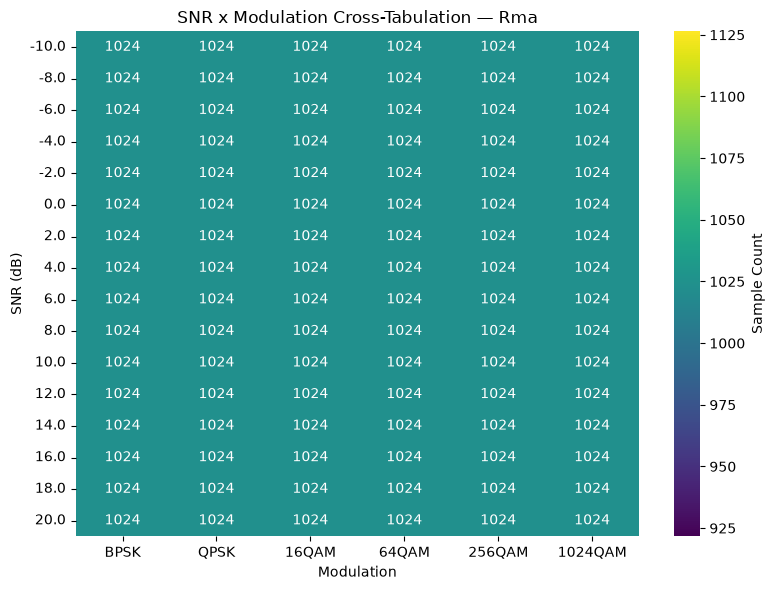


---- Uma ----
Mod    BPSK  QPSK  16QAM  64QAM  256QAM  1024QAM
SNR                                             
-10.0  1024  1024   1024   1024    1024     1024
-8.0   1024  1024   1024   1024    1024     1024
-6.0   1024  1024   1024   1024    1024     1024
-4.0   1024  1024   1024   1024    1024     1024
-2.0   1024  1024   1024   1024    1024     1024
 0.0   1024  1024   1024   1024    1024     1024
 2.0   1024  1024   1024   1024    1024     1024
 4.0   1024  1024   1024   1024    1024     1024
 6.0   1024  1024   1024   1024    1024     1024
 8.0   1024  1024   1024   1024    1024     1024
 10.0  1024  1024   1024   1024    1024     1024
 12.0  1024  1024   1024   1024    1024     1024
 14.0  1024  1024   1024   1024    1024     1024
 16.0  1024  1024   1024   1024    1024     1024
 18.0  1024  1024   1024   1024    1024     1024
 20.0  1024  1024   1024   1024    1024     1024

All cells == 1024: True


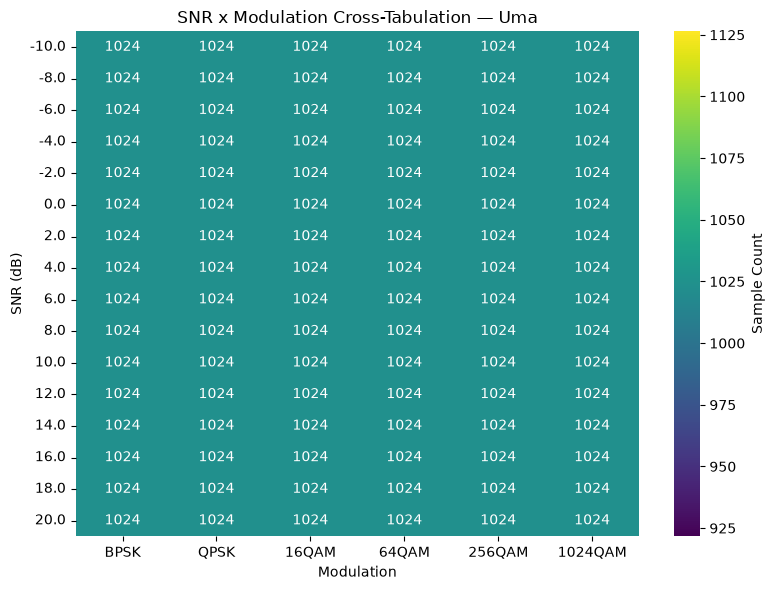


---- Umi ----
Mod    BPSK  QPSK  16QAM  64QAM  256QAM  1024QAM
SNR                                             
-10.0  1024  1024   1024   1024    1024     1024
-8.0   1024  1024   1024   1024    1024     1024
-6.0   1024  1024   1024   1024    1024     1024
-4.0   1024  1024   1024   1024    1024     1024
-2.0   1024  1024   1024   1024    1024     1024
 0.0   1024  1024   1024   1024    1024     1024
 2.0   1024  1024   1024   1024    1024     1024
 4.0   1024  1024   1024   1024    1024     1024
 6.0   1024  1024   1024   1024    1024     1024
 8.0   1024  1024   1024   1024    1024     1024
 10.0  1024  1024   1024   1024    1024     1024
 12.0  1024  1024   1024   1024    1024     1024
 14.0  1024  1024   1024   1024    1024     1024
 16.0  1024  1024   1024   1024    1024     1024
 18.0  1024  1024   1024   1024    1024     1024
 20.0  1024  1024   1024   1024    1024     1024

All cells == 1024: True


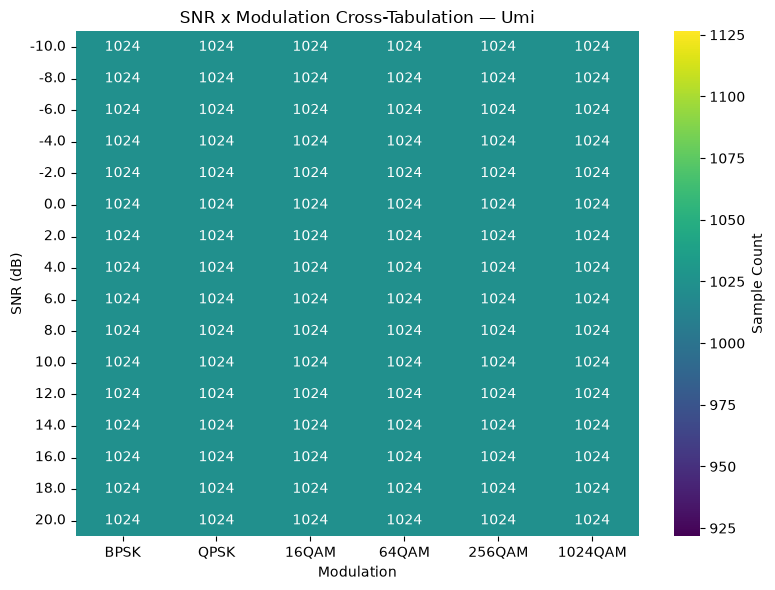

In [11]:
for label, s in SCENARIOS.items():
    df = pd.DataFrame({'SNR': s['snrs'], 'Mod': s['mod_labels']})
    crosstab = pd.crosstab(df['SNR'], df['Mod'])[MOD_NAMES]

    print(f"---- {label} ----")
    print(crosstab)

    expected_count = crosstab.values[0, 0]
    all_equal = (crosstab.values == expected_count).all()
    print(f"\nAll cells == {expected_count}: {all_equal}")
    if not all_equal:
        for r, c in np.argwhere(crosstab.values != expected_count):
            print(f"  MISMATCH: SNR={crosstab.index[r]}, Mod={crosstab.columns[c]}, count={crosstab.values[r, c]}")

    plt.figure(figsize=(8, 6))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='viridis', cbar_kws={'label': 'Sample Count'})
    plt.title(f"SNR x Modulation Cross-Tabulation — {label}")
    plt.xlabel("Modulation")
    plt.ylabel("SNR (dB)")
    plt.tight_layout()
    plt.show()
    print()

## 8. Cross-Modulation Energy Consistency @ 20 dB

In [12]:
for label, s in SCENARIOS.items():
    print(f"---- {label} @ {TARGET_SNR} dB ----")
    mask_snr = np.isclose(s['snrs'], TARGET_SNR)

    energies = {}
    for m in MOD_NAMES:
        mask = mask_snr & (s['mod_labels'] == m)
        sig = s['data'][mask]
        energies[m] = np.mean(np.abs(sig) ** 2)
        print(f"  {m:8s}: mean energy = {energies[m]:.4f}  (n={mask.sum()})")

    vals = np.array(list(energies.values()))
    print(f"  --> Spread: min={vals.min():.4f}, max={vals.max():.4f}, ratio max/min={vals.max()/vals.min():.3f}\n")

---- Rma @ 20.0 dB ----
  BPSK    : mean energy = 1.0101  (n=1024)
  QPSK    : mean energy = 1.0050  (n=1024)
  16QAM   : mean energy = 1.0017  (n=1024)
  64QAM   : mean energy = 1.0019  (n=1024)
  256QAM  : mean energy = 1.0010  (n=1024)
  1024QAM : mean energy = 0.9992  (n=1024)
  --> Spread: min=0.9992, max=1.0101, ratio max/min=1.011

---- Uma @ 20.0 dB ----
  BPSK    : mean energy = 1.0099  (n=1024)
  QPSK    : mean energy = 1.0046  (n=1024)
  16QAM   : mean energy = 1.0040  (n=1024)
  64QAM   : mean energy = 1.0017  (n=1024)
  256QAM  : mean energy = 1.0006  (n=1024)
  1024QAM : mean energy = 1.0019  (n=1024)
  --> Spread: min=1.0006, max=1.0099, ratio max/min=1.009

---- Umi @ 20.0 dB ----
  BPSK    : mean energy = 1.0100  (n=1024)
  QPSK    : mean energy = 1.0048  (n=1024)
  16QAM   : mean energy = 1.0026  (n=1024)
  64QAM   : mean energy = 1.0022  (n=1024)
  256QAM  : mean energy = 1.0011  (n=1024)
  1024QAM : mean energy = 1.0010  (n=1024)
  --> Spread: min=1.0010, max=1.0100

## 9. Peak-to-Average Power Ratio (PAPR)

(The original notebook ran this same check three times in a row with
identical code — merged into one cell.)

In [13]:
def compute_papr_db(signal):
    """Mean PAPR in dB for a batch of complex vectors, shape (N, T)."""
    power = np.abs(signal) ** 2
    papr_linear = power.max(axis=1) / power.mean(axis=1)
    return 10 * np.log10(papr_linear.mean())

QAM_ORDER = ['16QAM', '64QAM', '256QAM', '1024QAM']

for label, s in SCENARIOS.items():
    mask_snr = np.isclose(s['snrs'], TARGET_SNR)

    papr_db = {
        m: compute_papr_db(s['data'][mask_snr & (s['mod_labels'] == m)])
        for m in MOD_NAMES
    }

    print(f"---- {label} @ {TARGET_SNR} dB ----")
    print("PAPR (dB): " + ", ".join(f"{m}={papr_db[m]:.2f}" for m in MOD_NAMES))

    gap = papr_db['BPSK'] - papr_db['QPSK']
    print(f"  BPSK - QPSK = {gap:+.2f} dB ({'BPSK higher' if gap > 0 else 'QPSK higher or equal'})")

    qam_vals = [papr_db[m] for m in QAM_ORDER]
    monotonic = all(qam_vals[i] < qam_vals[i + 1] for i in range(len(qam_vals) - 1))
    print(f"  QAM monotonic increasing: {monotonic}\n")

---- Rma @ 20.0 dB ----
PAPR (dB): BPSK=1.95, QPSK=1.54, 16QAM=3.34, 64QAM=4.16, 256QAM=4.56, 1024QAM=4.71
  BPSK - QPSK = +0.41 dB (BPSK higher)
  QAM monotonic increasing: True

---- Uma @ 20.0 dB ----
PAPR (dB): BPSK=3.02, QPSK=2.67, 16QAM=4.17, 64QAM=4.95, 256QAM=5.18, 1024QAM=5.20
  BPSK - QPSK = +0.35 dB (BPSK higher)
  QAM monotonic increasing: True

---- Umi @ 20.0 dB ----
PAPR (dB): BPSK=2.90, QPSK=2.39, 16QAM=3.99, 64QAM=4.80, 256QAM=5.03, 1024QAM=5.09
  BPSK - QPSK = +0.51 dB (BPSK higher)
  QAM monotonic increasing: True



## 10. Constellation Grids — one clean vector per (Modulation, SNR)

This is the approach your teacher suggested: instead of stacking many
*independent* vectors (each its own noise/fading draw) into one overlapping
scatter plot, each panel below shows `n_vectors` full waveform(s) for a
single modulation/SNR combination. That keeps each panel legible and makes
it easy to compare shape and spread across modulations (rows) and SNRs
(columns) directly.

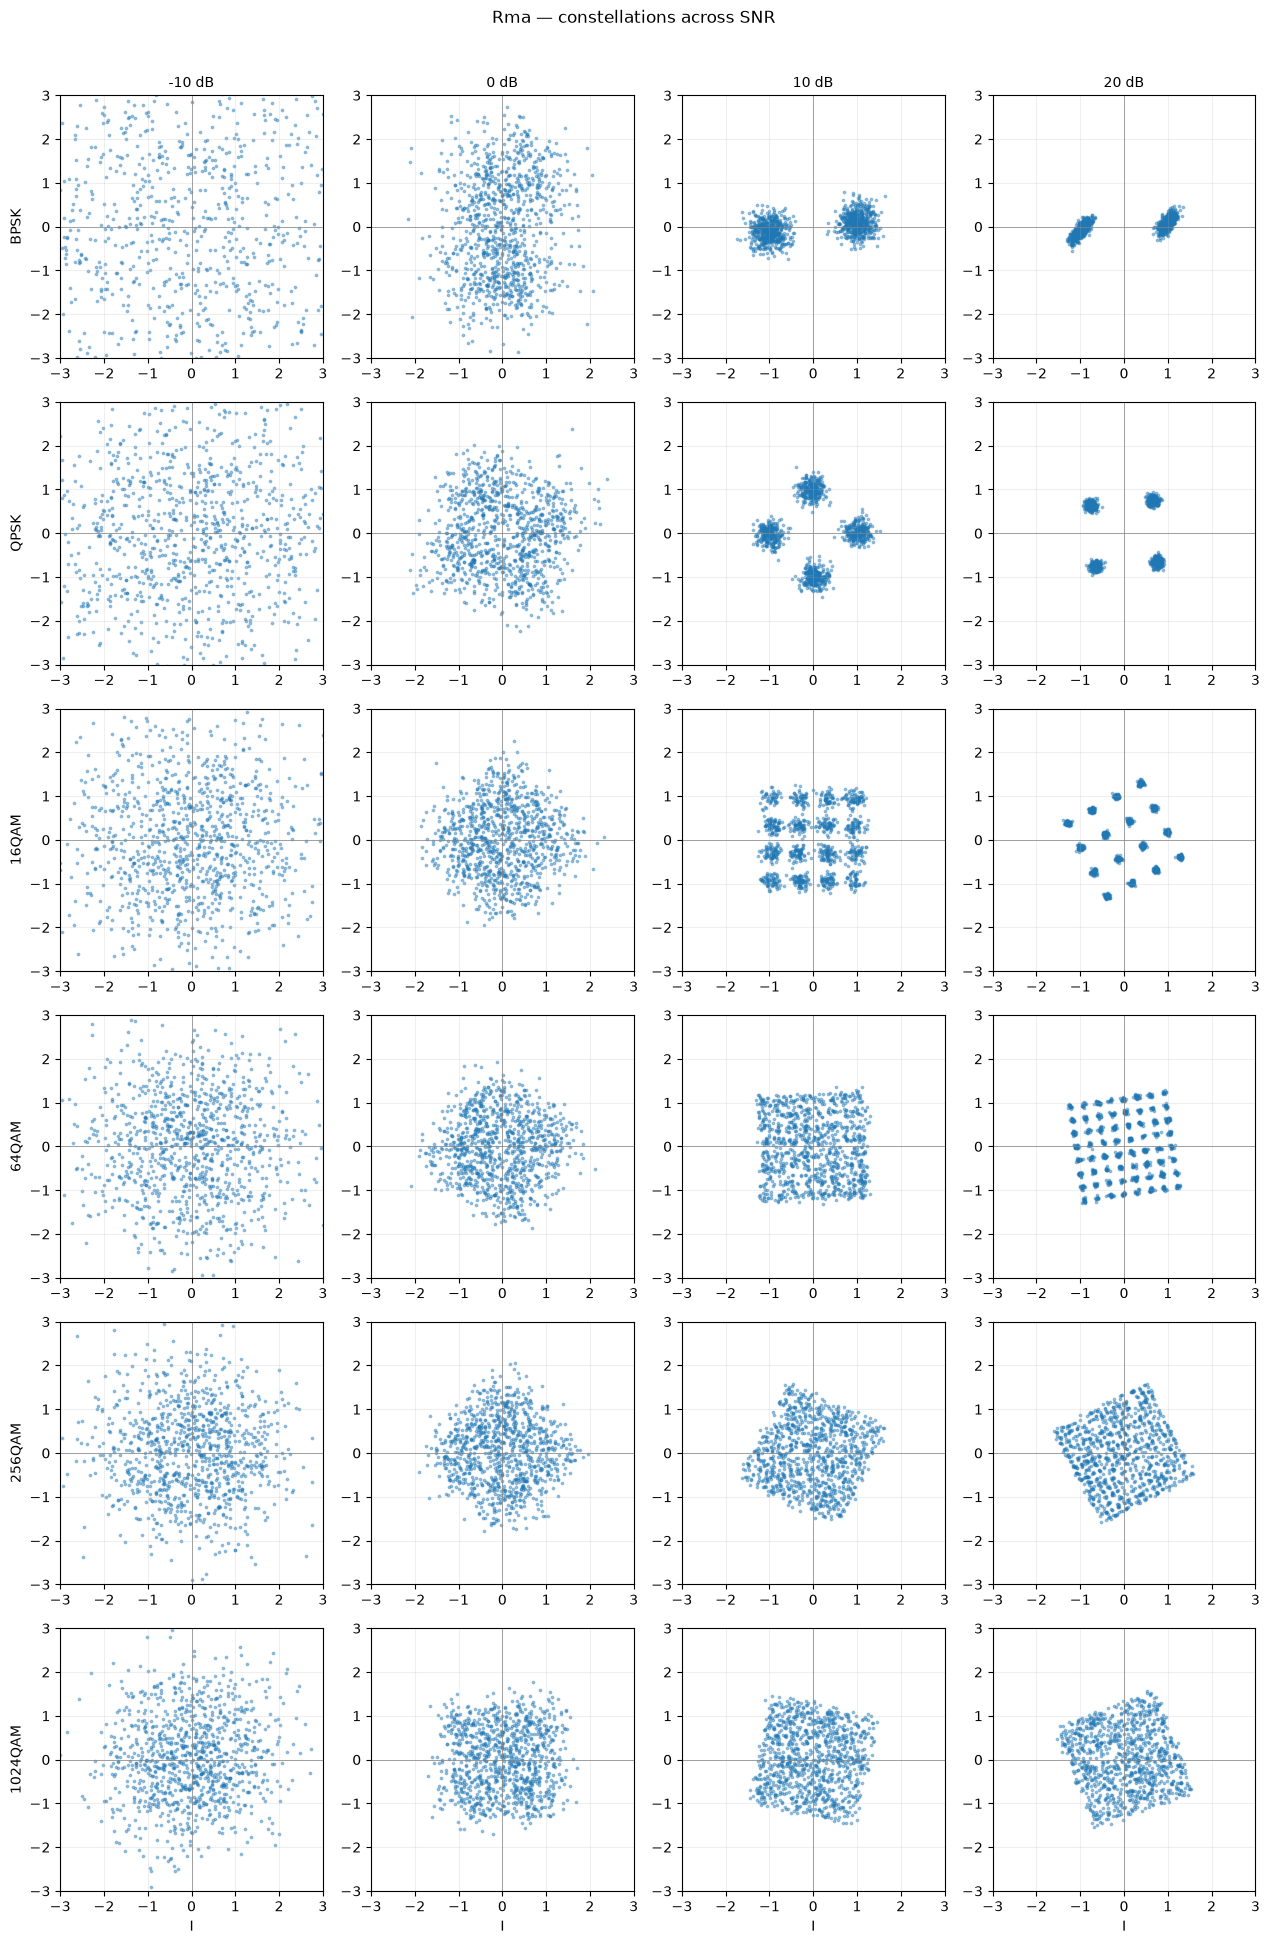

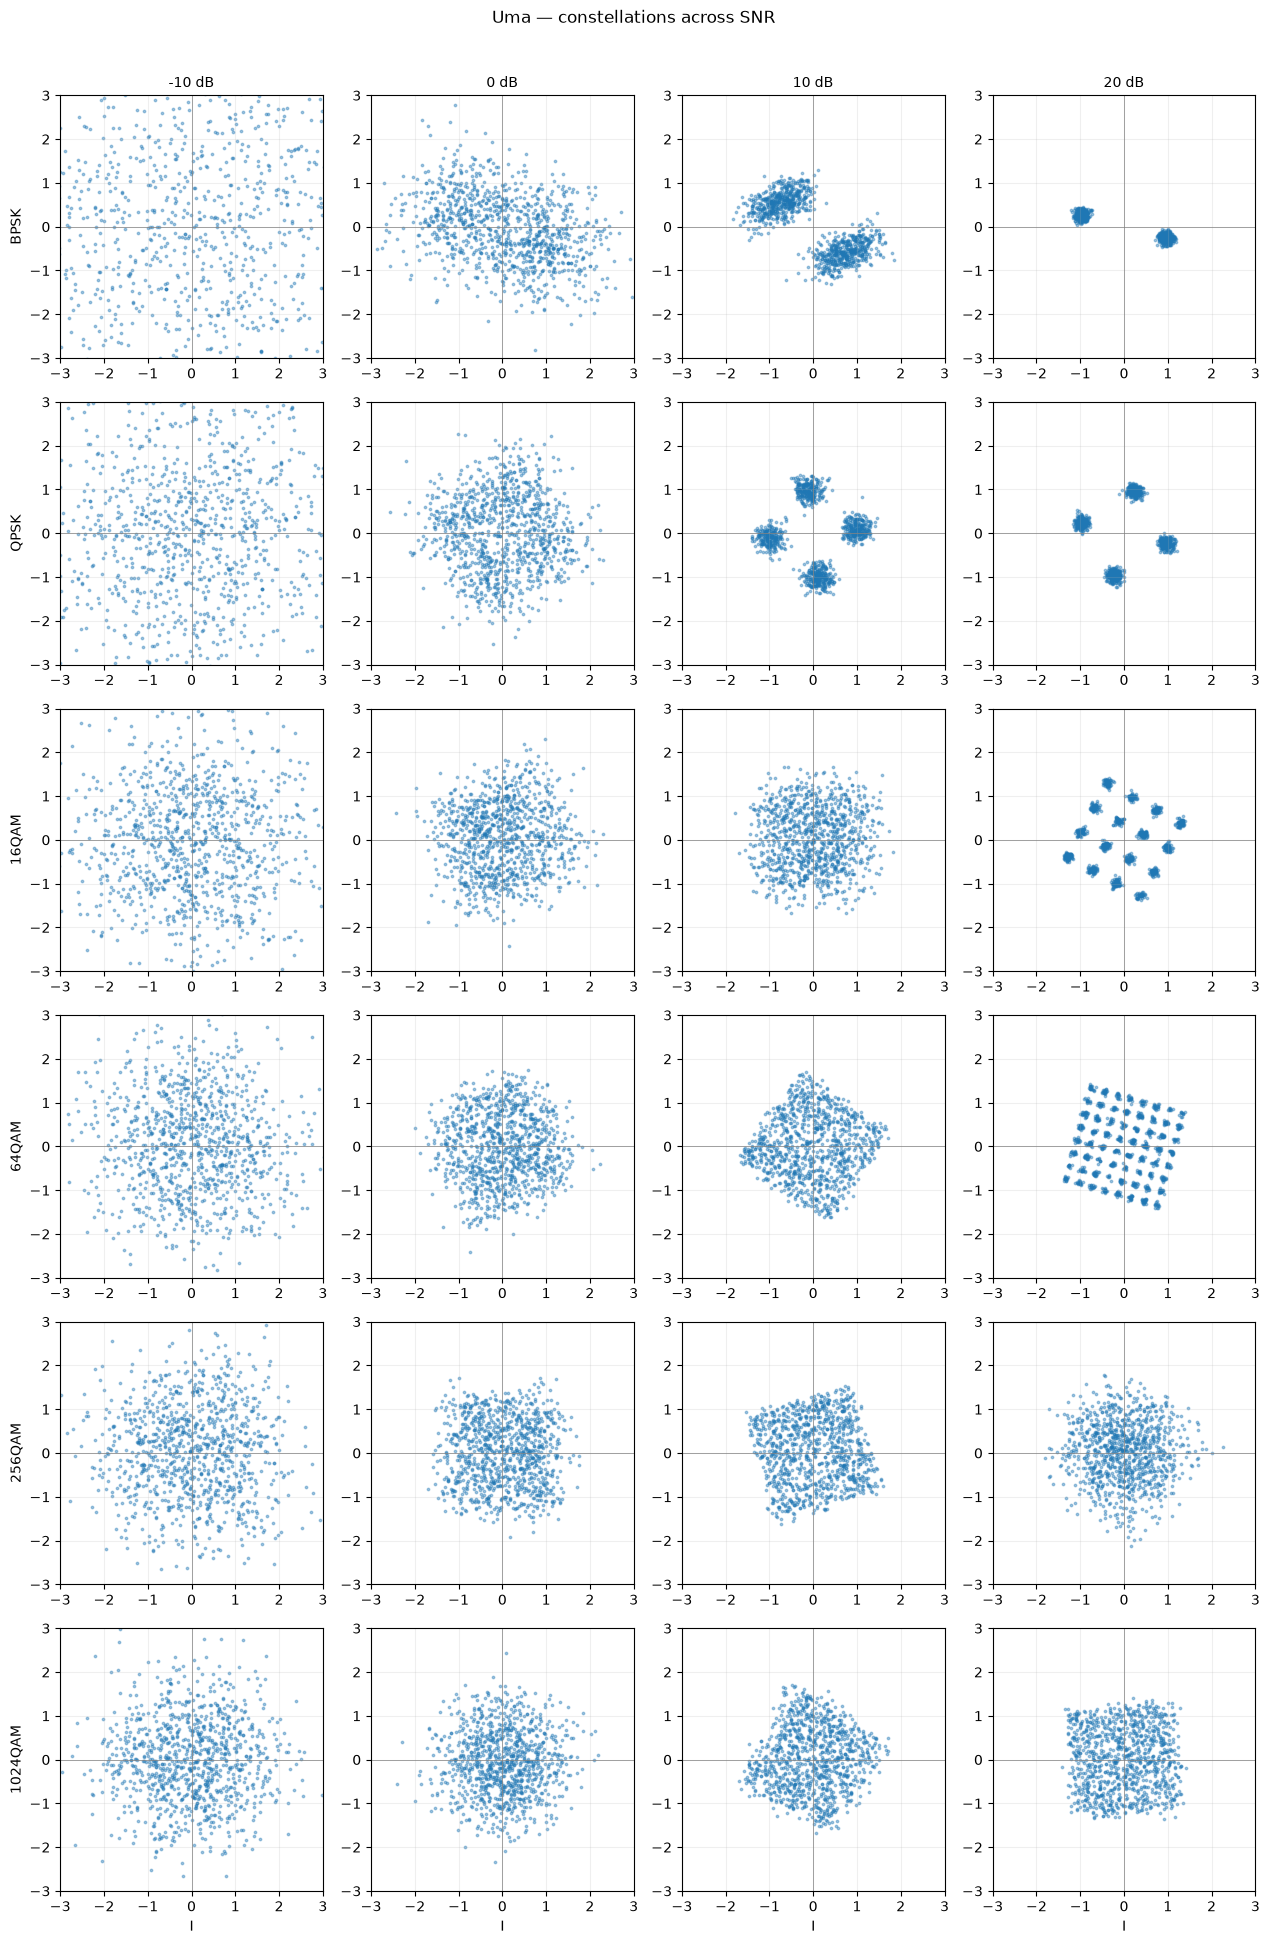

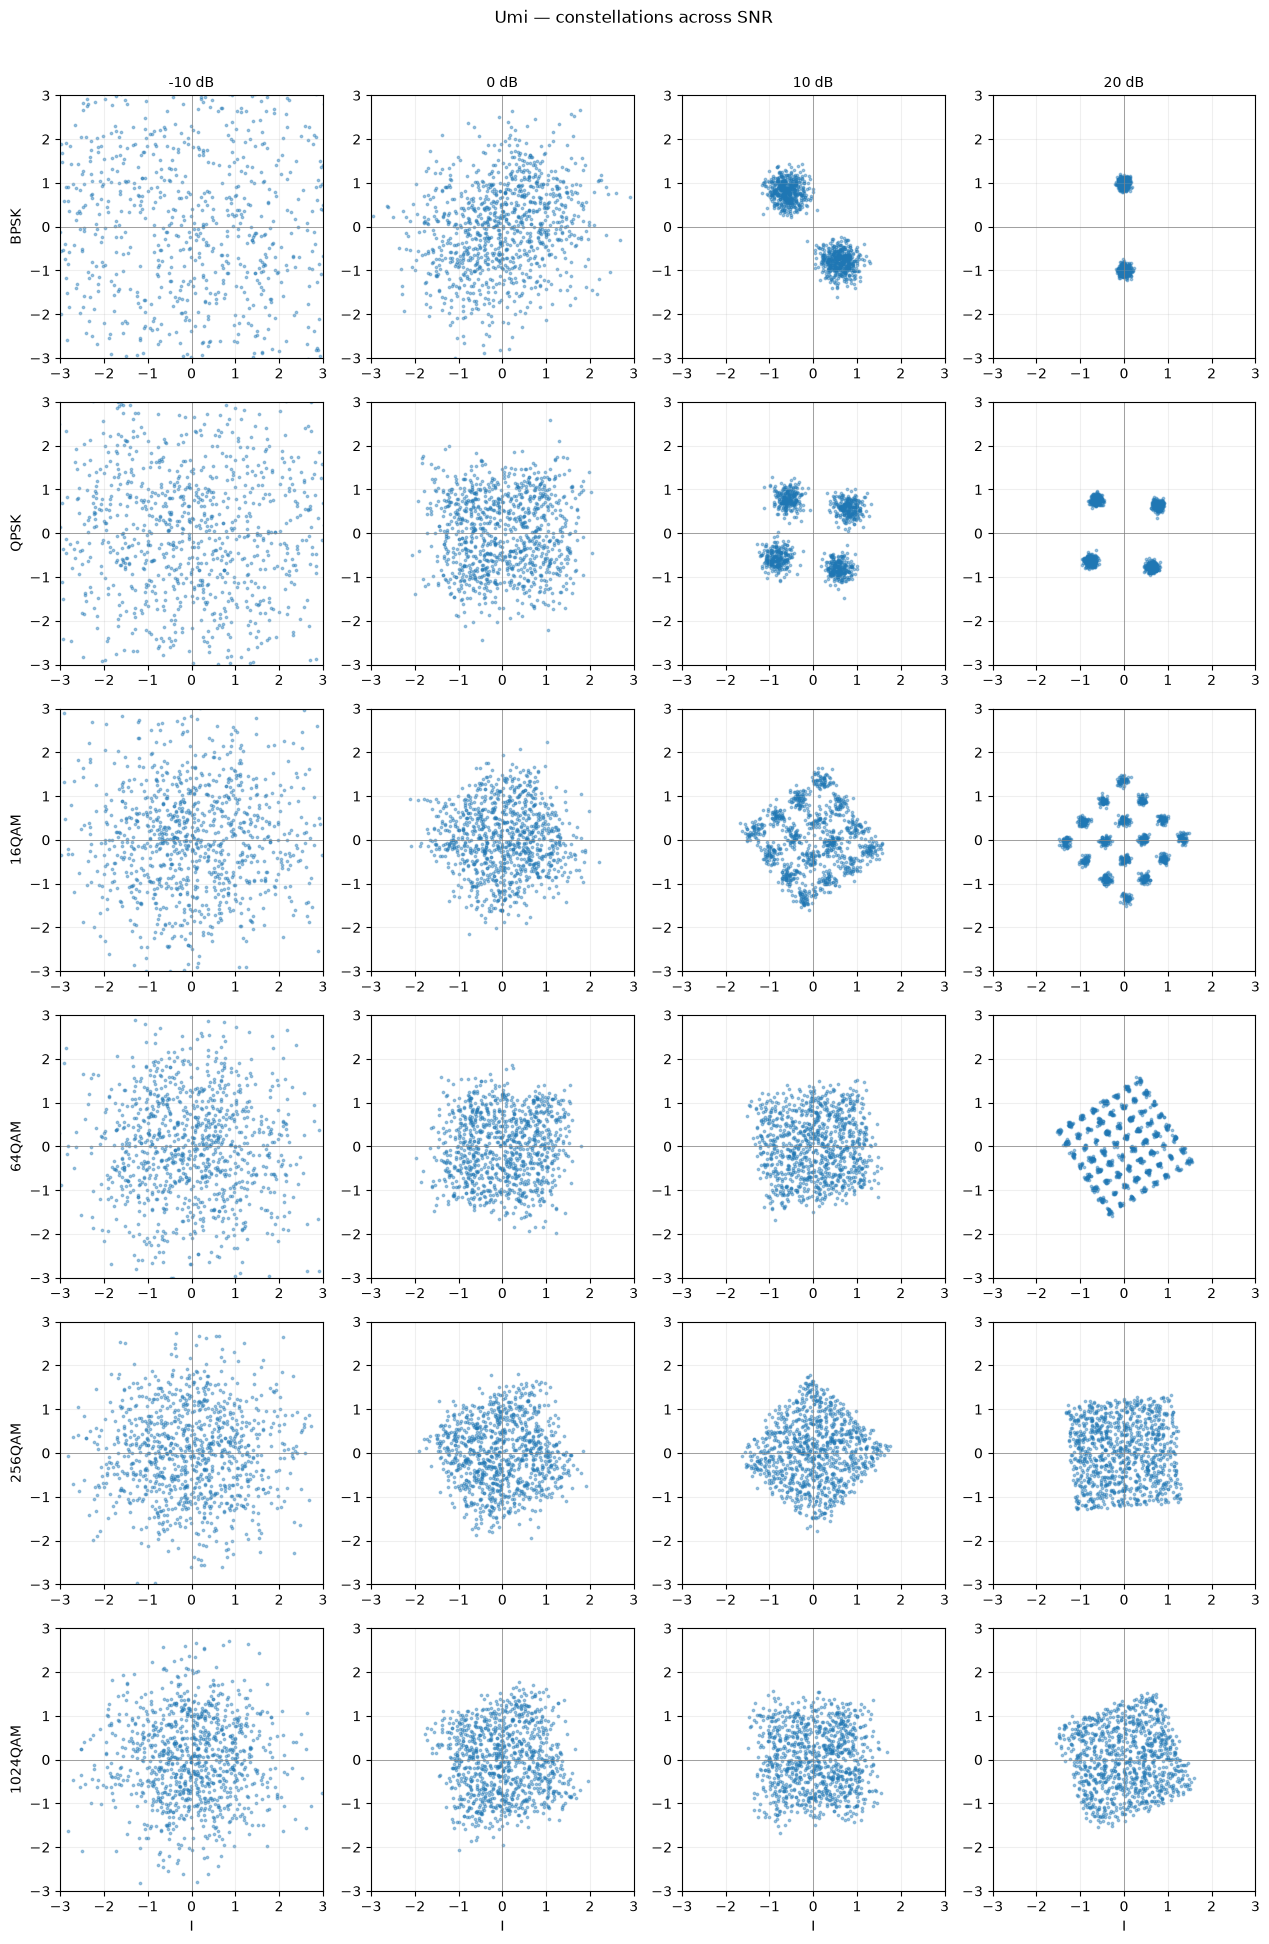

In [14]:
def plot_constellation_grid(label, s, snrs=FOCUS_SNRS, mods=MOD_NAMES, axis_limit=3, n_vectors=1):
    """Grid of constellation scatter plots: rows = modulations, cols = SNRs.

    Each panel plots `n_vectors` full data vectors for that exact
    (modulation, SNR) pair — never a mix of vectors from different SNRs or
    modulations, and never so many independent vectors that the plot turns
    into an uninterpretable blob.
    """
    n_mods, n_snrs = len(mods), len(snrs)
    fig, axes = plt.subplots(n_mods, n_snrs, figsize=(3.2 * n_snrs, 3.2 * n_mods), squeeze=False)
    fig.suptitle(f"{label} — constellations across SNR", y=1.01)

    for i, mod_name in enumerate(mods):
        mod_mask = s['mod_labels'] == mod_name

        for j, snr in enumerate(snrs):
            ax = axes[i, j]
            row_mask = mod_mask & np.isclose(s['snrs'], snr)
            available = s['data'][row_mask]

            if len(available) == 0:
                ax.set_visible(False)
                continue

            sample = available[:n_vectors].flatten()
            ax.scatter(sample.real, sample.imag, s=3, alpha=0.4)
            ax.axhline(0, color='gray', lw=0.5)
            ax.axvline(0, color='gray', lw=0.5)
            ax.set_xlim(-axis_limit, axis_limit)
            ax.set_ylim(-axis_limit, axis_limit)
            ax.set_aspect('equal')
            ax.grid(alpha=0.2)

            if i == 0:
                ax.set_title(f"{snr:g} dB", fontsize=10)
            if j == 0:
                ax.set_ylabel(mod_name, fontsize=10)
            if i == n_mods - 1:
                ax.set_xlabel("I")

    plt.tight_layout()
    plt.show()

for label, s in SCENARIOS.items():
    plot_constellation_grid(label, s)

## 11. Fading Severity: Amplitude vs Time for a single vector

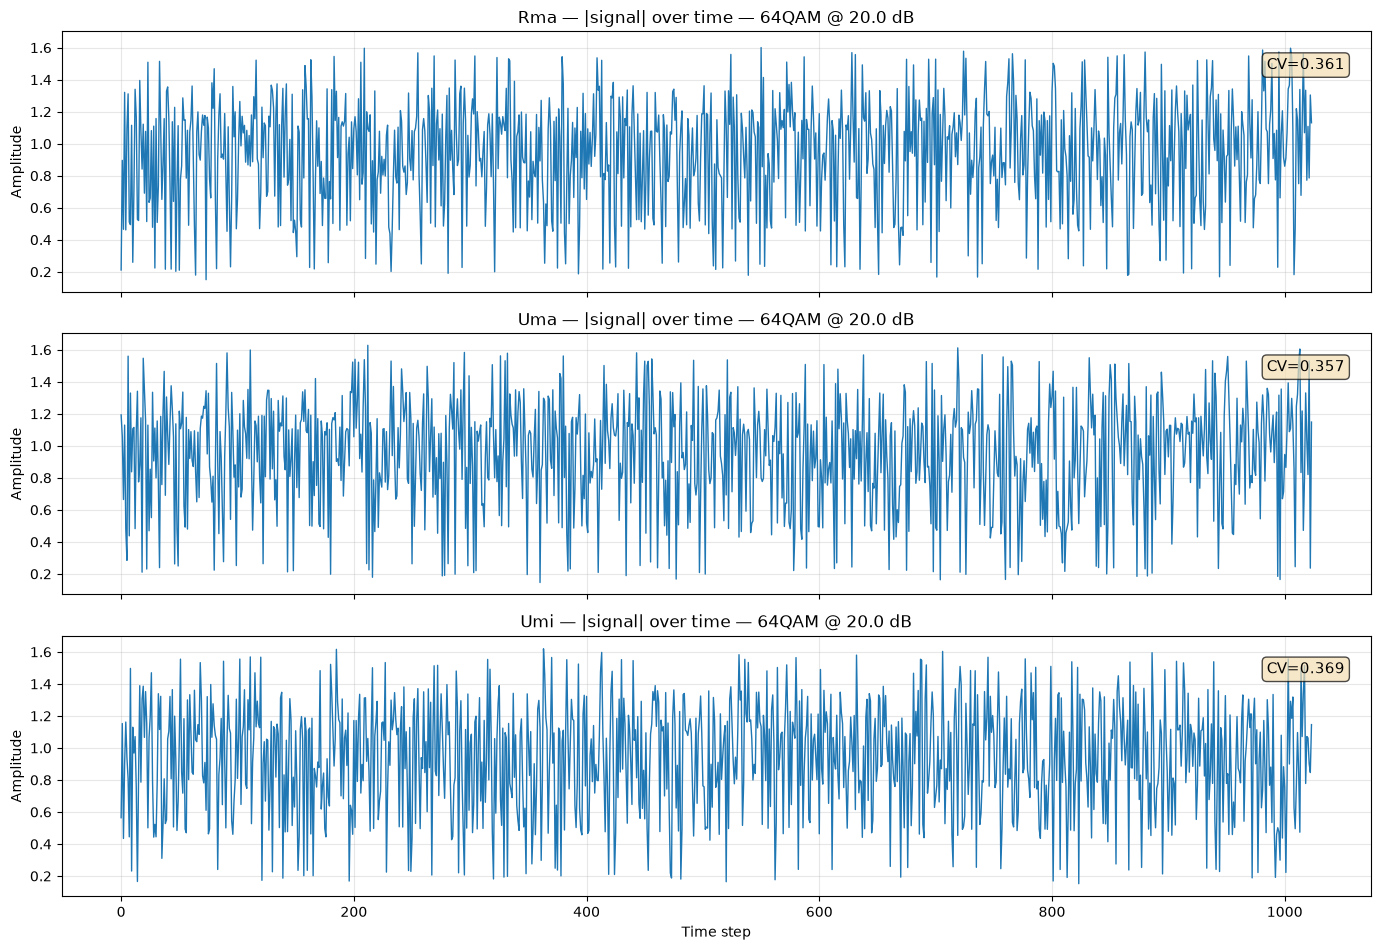

In [15]:
def plot_amplitude_trace(mod='64QAM', snr=20.0, vector_idx=0):
    fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(14, 3.2 * len(SCENARIOS)), sharex=True, sharey=True)

    for ax, (label, s) in zip(axes, SCENARIOS.items()):
        mask = np.isclose(s['snrs'], snr) & (s['mod_labels'] == mod)
        vec = s['data'][mask][vector_idx]
        amplitude = np.abs(vec)
        cv = amplitude.std() / amplitude.mean()

        ax.plot(amplitude, lw=1)
        ax.set_title(f"{label} — |signal| over time — {mod} @ {snr} dB")
        ax.set_ylabel("Amplitude")
        ax.grid(alpha=0.3)
        ax.text(0.98, 0.9, f"CV={cv:.3f}", transform=ax.transAxes, ha='right', va='top',
                fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    axes[-1].set_xlabel("Time step")
    plt.tight_layout()
    plt.show()

plot_amplitude_trace()

## 12. Fading Volatility, Quantified

`fading_cv` returns the per-vector coefficient of variation of `|amplitude|`
within each vector — one flexible function replaces what used to be three
separate cells (single-SNR summary, single-SNR-with-detail, and a
multi-SNR loop calling the same logic again).

In [16]:
def fading_cv(s, mod, snr, n_vectors=200):
    """Per-vector coefficient of variation of |amplitude| within each vector."""
    mask = np.isclose(s['snrs'], snr) & (s['mod_labels'] == mod)
    vecs = s['data'][mask][:n_vectors]
    amps = np.abs(vecs)
    return np.std(amps, axis=1) / np.mean(amps, axis=1)

for snr in [20.0, 10.0, 0.0]:
    print(f"=== 64QAM @ {snr} dB ===")
    for label, s in SCENARIOS.items():
        cvs = fading_cv(s, mod='64QAM', snr=snr)
        print(f"  {label:4s}: mean CV = {cvs.mean():.4f}, std across vectors = {cvs.std():.4f}")
    print()

=== 64QAM @ 20.0 dB ===
  Rma : mean CV = 0.3658, std across vectors = 0.0098
  Uma : mean CV = 0.3794, std across vectors = 0.0259
  Umi : mean CV = 0.3761, std across vectors = 0.0245

=== 64QAM @ 10.0 dB ===
  Rma : mean CV = 0.3726, std across vectors = 0.0112
  Uma : mean CV = 0.3871, std across vectors = 0.0289
  Umi : mean CV = 0.3841, std across vectors = 0.0255

=== 64QAM @ 0.0 dB ===
  Rma : mean CV = 0.4152, std across vectors = 0.0113
  Uma : mean CV = 0.4224, std across vectors = 0.0179
  Umi : mean CV = 0.4215, std across vectors = 0.0163



## 13. Summary: Fading Volatility Across Environments and SNRs

Mean fading CV by scenario and SNR — 64QAM

File     Rma     Uma     Umi
SNR                         
-10   0.5070  0.5088  0.5065
-8    0.4928  0.4957  0.4973
-6    0.4759  0.4796  0.4786
-4    0.4546  0.4587  0.4567
-2    0.4344  0.4394  0.4399
 0    0.4152  0.4224  0.4215
 2    0.4003  0.4095  0.4077
 4    0.3877  0.4003  0.3968
 6    0.3806  0.3940  0.3886
 8    0.3784  0.3888  0.3856
 10   0.3726  0.3871  0.3841
 12   0.3708  0.3825  0.3821
 14   0.3699  0.3796  0.3779
 16   0.3678  0.3798  0.3794
 18   0.3679  0.3770  0.3802
 20   0.3658  0.3794  0.3761


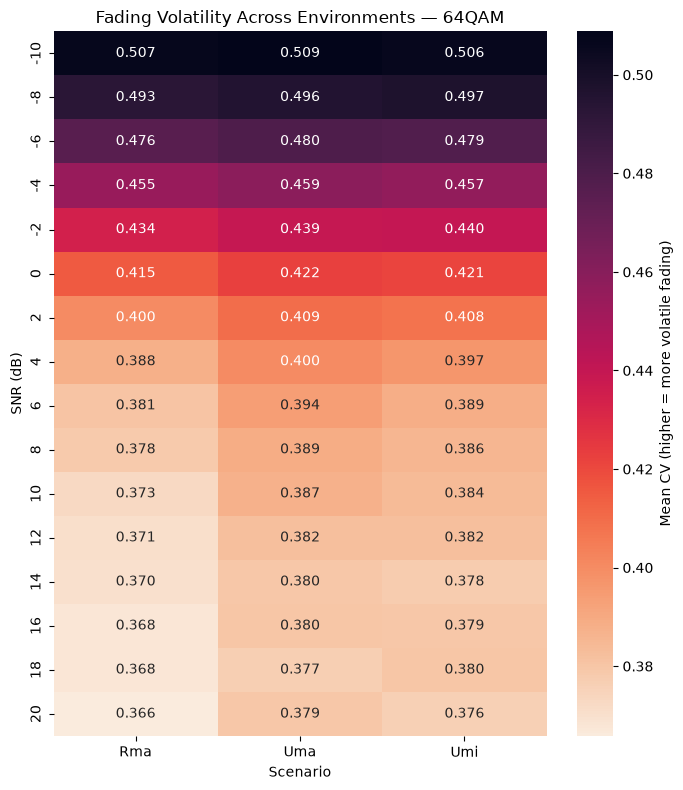

In [17]:
rows = []
for label, s in SCENARIOS.items():
    for snr in EXPECTED_SNRS:
        cvs = fading_cv(s, mod='64QAM', snr=snr)
        rows.append({'File': label, 'SNR': snr, 'MeanCV': cvs.mean()})

summary_df = pd.DataFrame(rows)
pivot_table = summary_df.pivot(index='SNR', columns='File', values='MeanCV')

print("Mean fading CV by scenario and SNR — 64QAM\n")
print(pivot_table.round(4))

plt.figure(figsize=(7, 8))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='rocket_r',
            cbar_kws={'label': 'Mean CV (higher = more volatile fading)'})
plt.title("Fading Volatility Across Environments — 64QAM")
plt.xlabel("Scenario")
plt.ylabel("SNR (dB)")
plt.tight_layout()
plt.show()

## 14. Diagnosing the constellation anomaly

The plots above show something that shouldn't happen if the labels are
correct: quality should degrade *smoothly* as modulation order increases
(BPSK → ... → 1024QAM), but instead some scenarios show a "good, bad, good,
bad" zigzag across the order sequence.

Rather than trust a single vector's random channel draw, this pools **all**
vectors for a given (scenario, modulation, SNR) and uses density-based
clustering (DBSCAN) to count how many distinct constellation points are
actually present — without assuming the order in advance. If a modulation
reliably shows a cluster count far from its expected order (and close to a
*different* modulation's expected order), that's strong evidence of a
label/column swap rather than a physical SNR effect.

In [18]:
# pip install scikit-learn --break-system-packages   # if not already installed
from sklearn.cluster import DBSCAN

MOD_ORDER = {'BPSK': 2, 'QPSK': 4, '16QAM': 16, '64QAM': 64, '256QAM': 256, '1024QAM': 1024}
DIAG_SNR = 20.0
N_VECTORS_FOR_DIAG = 100   # pool several vectors instead of trusting just one

def estimate_cluster_count(points, eps_frac=0.08, min_samples=5):
    """Rough count of distinct constellation points via DBSCAN.

    `eps_frac` is the clustering radius as a fraction of the RMS amplitude of
    the pooled points. Tune this if results look off — too small and every
    point becomes noise (-1 label), too large and separate clusters merge.
    """
    scale = np.sqrt(np.mean(np.abs(points[:, 0] + 1j * points[:, 1]) ** 2))
    eps = eps_frac * scale
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit(points).labels_
    return len(set(labels)) - (1 if -1 in labels else 0)

print(f"{'Scenario':8s} {'Mod':8s} {'Expected':>9s} {'Detected':>9s}  Note")
for label, s in SCENARIOS.items():
    for m in MOD_NAMES:
        mask = np.isclose(s['snrs'], DIAG_SNR) & (s['mod_labels'] == m)
        vecs = s['data'][mask][:N_VECTORS_FOR_DIAG]
        pts = np.column_stack([vecs.real.ravel(), vecs.imag.ravel()])

        n_detected = estimate_cluster_count(pts)
        expected = MOD_ORDER[m]

        note = ""
        if expected <= 64:  # DBSCAN is only reliable at these lower orders
            closest_mod = min(MOD_ORDER, key=lambda k: abs(MOD_ORDER[k] - n_detected))
            if closest_mod != m and abs(MOD_ORDER[closest_mod] - n_detected) < abs(expected - n_detected):
                note = f"<-- looks more like {closest_mod} ({MOD_ORDER[closest_mod]} pts)"

        print(f"{label:8s} {m:8s} {expected:9d} {n_detected:9d}  {note}")

Scenario Mod       Expected  Detected  Note
Rma      BPSK             2         1  
Rma      QPSK             4         7  
Rma      16QAM           16         4  <-- looks more like QPSK (4 pts)
Rma      64QAM           64         1  <-- looks more like BPSK (2 pts)
Rma      256QAM         256         1  
Rma      1024QAM       1024         1  
Uma      BPSK             2         1  
Uma      QPSK             4         9  
Uma      16QAM           16         4  <-- looks more like QPSK (4 pts)
Uma      64QAM           64         4  <-- looks more like QPSK (4 pts)
Uma      256QAM         256         2  
Uma      1024QAM       1024         1  
Umi      BPSK             2         5  <-- looks more like QPSK (4 pts)
Umi      QPSK             4         5  
Umi      16QAM           16         3  <-- looks more like BPSK (2 pts)
Umi      64QAM           64         4  <-- looks more like QPSK (4 pts)
Umi      256QAM         256         2  
Umi      1024QAM       1024         1  


In [19]:
def check_power_spread(s, mod, snr):
    mask = np.isclose(s['snrs'], snr) & (s['mod_labels'] == mod)
    y = s['data'][mask]                      # [num_vectors, vector_len]
    rx_power = np.mean(np.abs(y) ** 2, axis=1)   # per-vector average power

    print(f"{mod} @ {snr} dB  (n_vectors={len(rx_power)})")
    print(f"  power min/median/max: {rx_power.min():.4g} / {np.median(rx_power):.4g} / {rx_power.max():.4g}")
    print(f"  max/min ratio: {rx_power.max()/rx_power.min():.2f}x  ({10*np.log10(rx_power.max()/rx_power.min()):.1f} dB spread)")
    return rx_power

# Run across a few SNRs for one scenario/mod to see if the spread is SNR-independent
for snr in [-10, 0, 10, 20]:
    check_power_spread(SCENARIOS['Uma'], 'QPSK', snr)

QPSK @ -10 dB  (n_vectors=1024)
  power min/median/max: 5.446 / 5.994 / 6.597
  max/min ratio: 1.21x  (0.8 dB spread)
QPSK @ 0 dB  (n_vectors=1024)
  power min/median/max: 1.389 / 1.498 / 1.629
  max/min ratio: 1.17x  (0.7 dB spread)
QPSK @ 10 dB  (n_vectors=1024)
  power min/median/max: 0.9904 / 1.05 / 1.127
  max/min ratio: 1.14x  (0.6 dB spread)
QPSK @ 20 dB  (n_vectors=1024)
  power min/median/max: 0.9421 / 1.005 / 1.055
  max/min ratio: 1.12x  (0.5 dB spread)


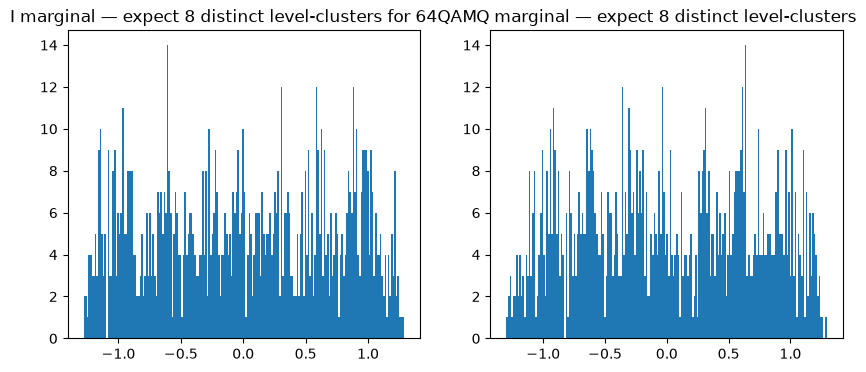

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# pick one Rma 64QAM vector at 20 dB
s = SCENARIOS['Rma']
mask = (s['mod_labels'] == '64QAM') & np.isclose(s['snrs'], 20.0)
y = s['data'][mask][0]   # one vector, shape (1024,)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y.real, bins=200)
axes[0].set_title("I marginal — expect 8 distinct level-clusters for 64QAM")
axes[1].hist(y.imag, bins=200)
axes[1].set_title("Q marginal — expect 8 distinct level-clusters")
plt.show()